# Analysis of the Gun Violence Dataset

# Part 1. &ndash; Problem Understanding & Data Understanding

Authors: Kacper Neumann, Stanisław Apanasiewicz, Jan Matusiak

----

## 1. The Dataset

### 1.1 General Information

The [Gun Violence Data](https://www.kaggle.com/datasets/jameslko/gun-violence-data) dataset contains detailed information about gun violence incidents in the United States, available in CSV format. It is based on records collected by the [Gun Violence Archive (GVA)](https://www.gunviolencearchive.org/), an independent organization created to provide a comprehensive database incidents in the U.S.

The CSV file contains data for all recorded gun violence incidents in the U.S. between January 2013 and March 2018.

In [67]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download('jameslko/gun-violence-data')
df = pd.read_csv(os.path.join(path, 'gun-violence-data_01-2013_03-2018.csv'))

In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 239677 entries, 0 to 239676
Data columns (total 29 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   incident_id                  239677 non-null  int64  
 1   date                         239677 non-null  str    
 2   state                        239677 non-null  str    
 3   city_or_county               239677 non-null  str    
 4   address                      223180 non-null  str    
 5   n_killed                     239677 non-null  int64  
 6   n_injured                    239677 non-null  int64  
 7   incident_url                 239677 non-null  str    
 8   source_url                   239209 non-null  str    
 9   incident_url_fields_missing  239677 non-null  bool   
 10  congressional_district       227733 non-null  float64
 11  gun_stolen                   140179 non-null  str    
 12  gun_type                     140226 non-null  str    
 13  incident_c

In [69]:
df['incident_id'].nunique()
df.set_index('incident_id', inplace=True)

There are 239677 samples described with 29 attributes each. There are no duplicate rows.

### 1.2 Attributes

let's see at numerical attributes first

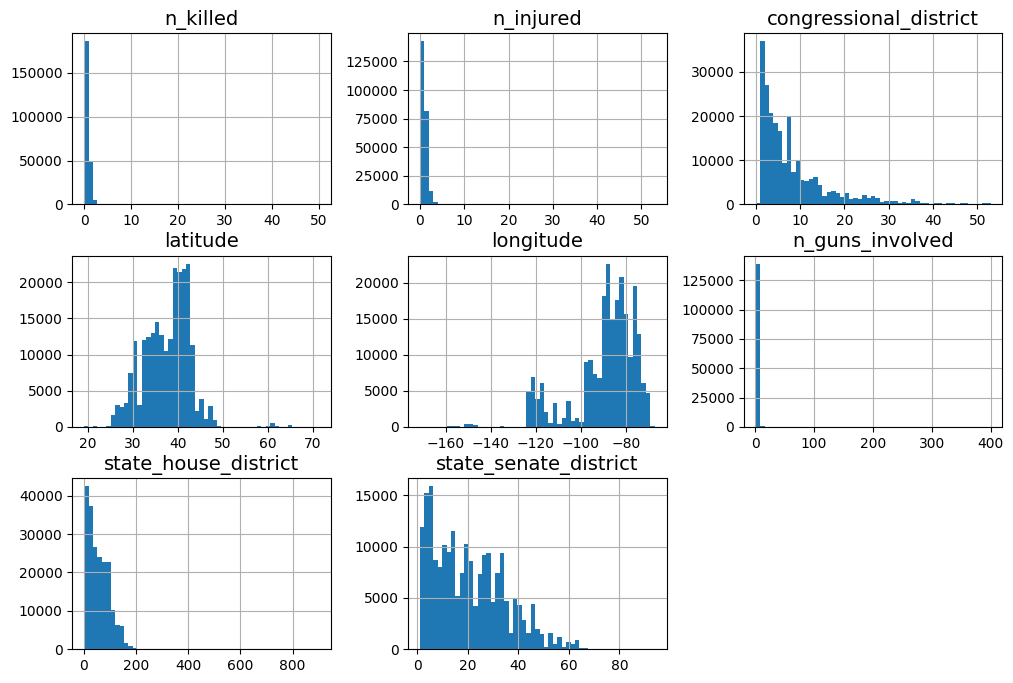

In [88]:
import matplotlib.pyplot as plt
df.hist(bins=53, figsize=(12, 8))

plt.show()

In [72]:
df.describe()

,n_killed,n_injured,congressional_district,latitude,longitude,n_guns_involved,state_house_district,state_senate_district
count,239677.000000,239677.000000,227733.000000,231754.000000,231754.000000,140226.000000,200905.000000,207342.00000
mean,0.252290,0.494007,8.001265,37.546598,-89.338348,1.372442,55.447132,20.47711
std,0.521779,0.729952,8.480835,5.130763,14.359546,4.678202,42.048117,14.20456
min,0.000000,0.000000,0.000000,19.111400,-171.429000,1.000000,1.000000,1.00000
25%,0.000000,0.000000,2.000000,33.903400,-94.158725,1.000000,21.000000,9.00000
50%,0.000000,0.000000,5.000000,38.570600,-86.249600,1.000000,47.000000,19.00000
75%,0.000000,1.000000,10.000000,41.437375,-80.048625,1.000000,84.000000,30.00000
max,50.000000,53.000000,53.000000,71.336800,97.433100,400.000000,901.000000,94.00000


the variables:
 'congressional_district' , 'state_senate_distict' and 'state_house_distict' 
 
 are integers, but they are assigned as a geographical divisions within a patricular state, so they need to be assigned to it. No point in seeing the correlation between them, they are actually categorical variables

it is also pointless to show latitude and longitude distributions separately, let's see a basic plot to see whether all of the data is in the within the USA

<Axes: xlabel='longitude', ylabel='latitude'>

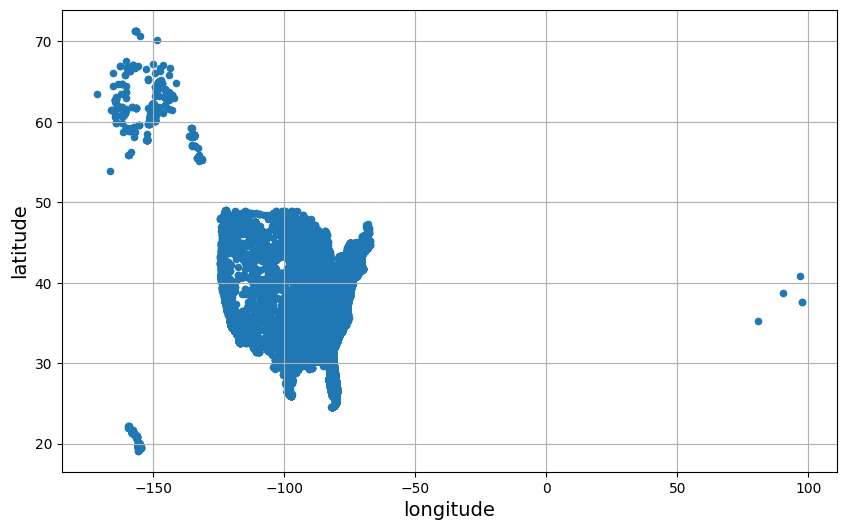

In [73]:
df.plot(x='longitude', y='latitude', kind='scatter', grid=True, figsize=(10, 6))

we can see 4 clusters here, the main USA land and Alaska can be seen very clearly. A cluster in a bottom left corner are Hawaii islands, it is also self explanatory. But the 4 dots at the right side of a plot are not that obvious.

In [74]:
pd.set_option('display.max_columns', None)
not_usa = df.loc[df['longitude']>0]
not_usa.head(10)
#nun = not_usa.to_numpy()
#print(nun)


,date,state,city_or_county,address,n_killed,n_injured,incident_url,source_url,incident_url_fields_missing,congressional_district,gun_stolen,gun_type,incident_characteristics,latitude,location_description,longitude,n_guns_involved,notes,participant_age,participant_age_group,participant_gender,participant_name,participant_relationship,participant_status,participant_type,sources,state_house_district,state_senate_district
incident_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,
989590,2017-11-15,Missouri,St Louis,NaN,0,0,http://www.gunviolencearchive.org/incident/989590,http://stlouis.cbslocal.com/2017/11/15/update-...,False,NaN,0::Unknown,0::9mm,Non-Shooting Incident||TSA Action,38.7487,NaN,90.3700,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://stlouis.cbslocal.com/2017/11/15/update-...,NaN,NaN
1012331,2017-12-22,North Carolina,Charlotte,NaN,0,0,http://www.gunviolencearchive.org/incident/101...,http://wlos.com/news/local/tsa-seizes-another-...,False,NaN,0::Unknown,0::38 Spl,Non-Shooting Incident||TSA Action,35.2137,NaN,80.9491,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://wlos.com/news/local/tsa-seizes-another-...,NaN,NaN
1075419,2018-03-20,Nebraska,Lincoln,NaN,0,0,http://www.gunviolencearchive.org/incident/107...,http://www.1011now.com/content/news/Handgun-fo...,False,NaN,0::Unknown,0::Handgun,Non-Shooting Incident||TSA Action,40.8509,NaN,96.7591,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.1011now.com/content/news/Handgun-fo...,NaN,NaN
1081194,2018-03-25,Kansas,Wichita,NaN,0,0,http://www.gunviolencearchive.org/incident/108...,http://www.kansas.com/news/local/crime/article...,False,NaN,0::Unknown,0::38 Spl,Non-Shooting Incident||TSA Action,37.6499,NaN,97.4331,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.kansas.com/news/local/crime/article...,NaN,NaN
1081193,2018-03-29,Kansas,Wichita,NaN,0,0,http://www.gunviolencearchive.org/incident/108...,http://www.kansas.com/news/local/crime/article...,False,NaN,0::Unknown,0::9mm,Non-Shooting Incident||TSA Action,37.6499,NaN,97.4331,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.kansas.com/news/local/crime/article...,NaN,NaN


It seems that these dots symbolise actually 5 events. They are all non shooting incidents and are classified as 'TSA Action'. These events describe incidents at airports and they all have little to no data describing them. We've looked at the coordinates in https://www.gps-coordinates.net/. All of these places are located in western part of China, but these places are random and do not point to anything.



*TSA -> Transportation Security Administration - an agency of the United States Department of Homeland Security (DHS) that has authority over the security of transportation systems within and connecting to the United States. It was created as a response to the September 11 attacks to improve airport security.

okay, we can see that someone who imputed this data made a mistake. These longitudes should be negative numbers, but they have been written as positive ones. If we take (-1 * longitude) we actually get places of airports stated in data. We can correct this data with confidence.


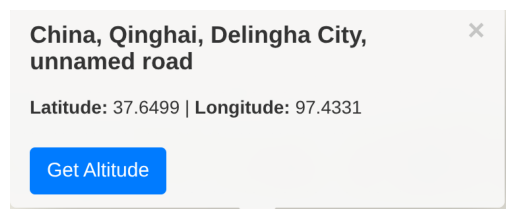

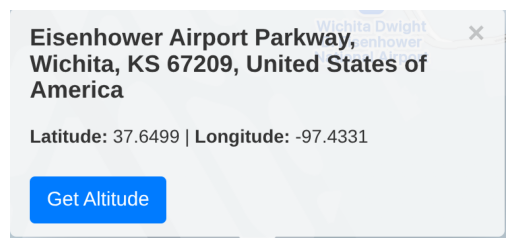

In [75]:
import matplotlib.image as mpimg

img1 = mpimg.imread('wrong_latitude.png')
plt.imshow(img1)
plt.axis('off') 
plt.show()
img2 = mpimg.imread('corrected_latitude.png')
plt.imshow(img2)
plt.axis('off')
plt.show()

In [76]:
df['longitude'] = df['longitude'].apply(lambda x: -x if x > 0 else x)

<Axes: xlabel='longitude', ylabel='latitude'>

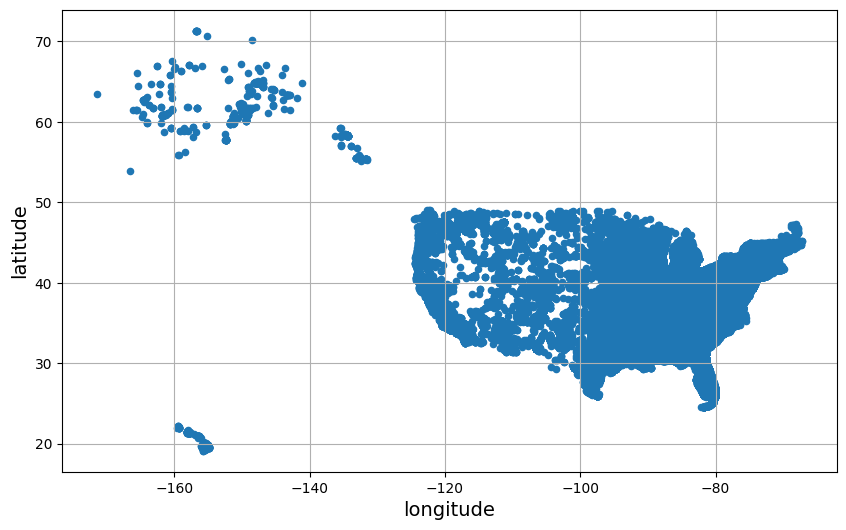

In [77]:
df.plot(x='longitude', y='latitude', kind='scatter', grid=True, figsize=(10, 6))

now the plot looks better, lets look at other numerical variables

In [78]:
df.describe()

,n_killed,n_injured,congressional_district,latitude,longitude,n_guns_involved,state_house_district,state_senate_district
count,239677.000000,239677.000000,227733.000000,231754.000000,231754.000000,140226.000000,200905.000000,207342.00000
mean,0.252290,0.494007,8.001265,37.546598,-89.342343,1.372442,55.447132,20.47711
std,0.521779,0.729952,8.480835,5.130763,14.334668,4.678202,42.048117,14.20456
min,0.000000,0.000000,0.000000,19.111400,-171.429000,1.000000,1.000000,1.00000
25%,0.000000,0.000000,2.000000,33.903400,-94.159175,1.000000,21.000000,9.00000
50%,0.000000,0.000000,5.000000,38.570600,-86.249650,1.000000,47.000000,19.00000
75%,0.000000,1.000000,10.000000,41.437375,-80.048975,1.000000,84.000000,30.00000
max,50.000000,53.000000,53.000000,71.336800,-67.271100,400.000000,901.000000,94.00000


co

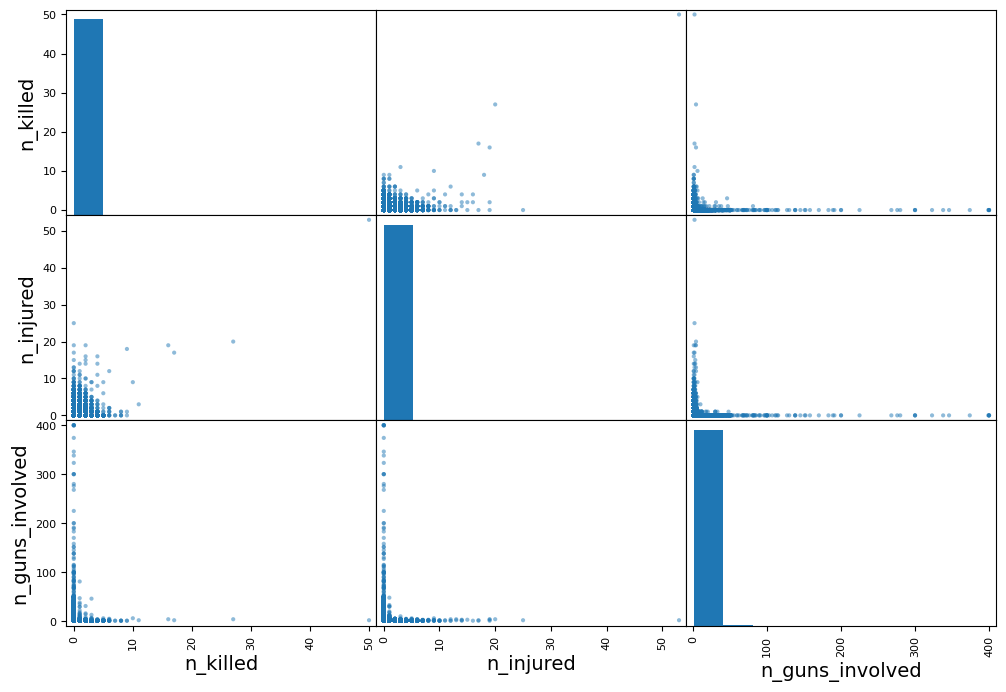

In [86]:
from pandas.plotting import scatter_matrix

attributes = ["n_killed", "n_injured", "n_guns_involved"]
scatter_matrix(df[attributes], figsize=(12, 8))

plt.show()

## 2. Data Mining Goals & Success Criteria

TODO